In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

In [3]:
# Função objetivo
def f(x):
    return 1 - x**2

# Parâmetros
a = -2          # extremo esquerdo do intervalo
b = 2           # extremo direito
n_bits = 4      # número de bits
total_valores = 2**n_bits  # 16 valores possíveis
delta_x = (b - a) / (total_valores - 1)  # espaçamento

print(f"Intervalo: [{a}, {b}]")
print(f"Número de bits: {n_bits}")
print(f"Total de valores possíveis: {total_valores}")
print(f"Espaçamento entre valores: {delta_x:.4f}")
print(f"Valor exato do máximo: x = 0, f(0) = 1")

Intervalo: [-2, 2]
Número de bits: 4
Total de valores possíveis: 16
Espaçamento entre valores: 0.2667
Valor exato do máximo: x = 0, f(0) = 1


In [4]:
def binario_para_decimal(bits):
    """Converte uma string de bits para decimal"""
    decimal = 0
    for i, bit in enumerate(bits[::-1]):  # percorre da direita para esquerda
        decimal += int(bit) * (2**i)
    return decimal

def decimal_para_real(d):
    """Converte decimal para valor real x no intervalo [a, b]"""
    return a + (d / (2**n_bits - 1)) * (b - a)

def binario_para_real(bits):
    """Converte diretamente bits para valor real"""
    d = binario_para_decimal(bits)
    return decimal_para_real(d)

def real_para_binario(x):
    """Converte valor real para binário (usando a grade discreta)"""
    # Encontra o decimal mais próximo
    d = round((x - a) / (b - a) * (2**n_bits - 1))
    d = max(0, min(d, 2**n_bits - 1))  # garante dentro dos limites
    # Converte para binário com 4 bits
    return format(d, f'0{n_bits}b')

# Exemplos do PDF
print("Exemplos do PDF:")
print(f"0000 → decimal: {binario_para_decimal('0000')} → x = {binario_para_real('0000'):.4f}")
print(f"0011 → decimal: {binario_para_decimal('0011')} → x = {binario_para_real('0011'):.4f}")
print(f"0111 → decimal: {binario_para_decimal('0111')} → x = {binario_para_real('0111'):.4f}")
print(f"1111 → decimal: {binario_para_decimal('1111')} → x = {binario_para_real('1111'):.4f}")

Exemplos do PDF:
0000 → decimal: 0 → x = -2.0000
0011 → decimal: 3 → x = -1.2000
0111 → decimal: 7 → x = -0.1333
1111 → decimal: 15 → x = 2.0000


In [5]:
print("Tabela de todos os 16 cromossomos possíveis:")
print("-" * 50)
print(f"{'Cromossomo':<10} {'Decimal':<8} {'Valor x':<10} {'f(x) = 1-x²':<12}")
print("-" * 50)

for d in range(total_valores):
    bits = format(d, f'0{n_bits}b')
    x = decimal_para_real(d)
    fitness = f(x)
    print(f"{bits:<10} {d:<8} {x:<10.4f} {fitness:<12.4f}")

Tabela de todos os 16 cromossomos possíveis:
--------------------------------------------------
Cromossomo Decimal  Valor x    f(x) = 1-x² 
--------------------------------------------------
0000       0        -2.0000    -3.0000     
0001       1        -1.7333    -2.0044     
0010       2        -1.4667    -1.1511     
0011       3        -1.2000    -0.4400     
0100       4        -0.9333    0.1289      
0101       5        -0.6667    0.5556      
0110       6        -0.4000    0.8400      
0111       7        -0.1333    0.9822      
1000       8        0.1333     0.9822      
1001       9        0.4000     0.8400      
1010       10       0.6667     0.5556      
1011       11       0.9333     0.1289      
1100       12       1.2000     -0.4400     
1101       13       1.4667     -1.1511     
1110       14       1.7333     -2.0044     
1111       15       2.0000     -3.0000     


In [6]:
def selecionar_pais(populacao, fitness):
    """Seleção por torneio (escolhe os dois melhores como no exemplo)"""
    # Ordena por fitness decrescente
    indices_ordenados = np.argsort(fitness)[::-1]
    # Pega os dois melhores
    pai1 = populacao[indices_ordenados[0]]
    pai2 = populacao[indices_ordenados[1]]
    return pai1, pai2

def crossover_ponto_único(pai1, pai2, ponto_corte):
    """Crossover de ponto único (como no PDF)"""
    # Divide os bits no ponto de corte
    parte1_pai1 = pai1[:ponto_corte]
    parte2_pai1 = pai1[ponto_corte:]
    parte1_pai2 = pai2[:ponto_corte]
    parte2_pai2 = pai2[ponto_corte:]
    
    # Troca as partes à direita do corte
    filho1 = parte1_pai1 + parte2_pai2
    filho2 = parte1_pai2 + parte2_pai1
    
    return filho1, filho2

def mutacao(bits, taxa=0.25):
    """Mutação: altera um bit aleatoriamente"""
    if np.random.random() < taxa:
        posicao = np.random.randint(len(bits))
        bits_lista = list(bits)
        bits_lista[posicao] = '1' if bits_lista[posicao] == '0' else '0'
        return ''.join(bits_lista)
    return bits

In [7]:
print("="*60)
print("EXEMPLO DO PDF - PASSO A PASSO")
print("="*60)

# População inicial do PDF
populacao_inicial = ['0011', '0110', '1011', '1110']
print(f"\n1. População inicial: {populacao_inicial}")

# Calcular fitness
print("\n2. Avaliação da aptidão:")
print("-"*60)
print(f"{'Cromossomo':<10} {'Decimal':<8} {'x':<10} {'f(x) = 1-x²':<12} {'Qualidade':<12}")
print("-"*60)

valores_x = []
fitness_values = []
for bits in populacao_inicial:
    d = binario_para_decimal(bits)
    x = decimal_para_real(d)
    fit = f(x)
    valores_x.append(x)
    fitness_values.append(fit)
    
    if fit < 0:
        qual = "muito baixa"
    elif fit < 0.5:
        qual = "baixa"
    elif fit < 0.9:
        qual = "média"
    else:
        qual = "boa"
    
    print(f"{bits:<10} {d:<8} {x:<10.4f} {fit:<12.4f} {qual:<12}")

# Seleção dos pais
print("\n3. Seleção:")
pai1, pai2 = selecionar_pais(populacao_inicial, fitness_values)
print(f"   Melhores indivíduos (pais): {pai1} e {pai2}")

# Crossover
print("\n4. Cruzamento (ponto de corte após o segundo bit):")
print(f"   {pai1} = {pai1[:2]}|{pai1[2:]}")
print(f"   {pai2} = {pai2[:2]}|{pai2[2:]}")
filho1, filho2 = crossover_ponto_único(pai1, pai2, ponto_corte=2)
print(f"   Filhos: {filho1} e {filho2}")

# Avaliar filhos
print("\n5. Avaliação dos filhos:")
d1 = binario_para_decimal(filho1)
x1 = decimal_para_real(d1)
f1 = f(x1)
print(f"   Filho {filho1} → d={d1} → x={x1:.4f} → f(x)={f1:.4f}")

d2 = binario_para_decimal(filho2)
x2 = decimal_para_real(d2)
f2 = f(x2)
print(f"   Filho {filho2} → d={d2} → x={x2:.4f} → f(x)={f2:.4f}")

# Mutação
print("\n6. Mutação (aplicada no filho 1010):")
print(f"   Antes: {filho2}")
filho2_mutado = '1000'  # como no PDF
print(f"   Depois: {filho2_mutado}")

# Nova população
nova_populacao = [populacao_inicial[1], filho1, filho1, filho2_mutado]
print(f"\n7. Nova população: {nova_populacao}")

print("\n8. Melhoria observada:")
print(f"   Melhor da geração anterior: x = {max(valores_x):.4f}")
print(f"   Melhor da nova geração: x = 0.1333 (cromossomo 1000)")
print(f"   O algoritmo se aproximou de x = 0!")

EXEMPLO DO PDF - PASSO A PASSO

1. População inicial: ['0011', '0110', '1011', '1110']

2. Avaliação da aptidão:
------------------------------------------------------------
Cromossomo Decimal  x          f(x) = 1-x²  Qualidade   
------------------------------------------------------------
0011       3        -1.2000    -0.4400      muito baixa 
0110       6        -0.4000    0.8400       média       
1011       11       0.9333     0.1289       baixa       
1110       14       1.7333     -2.0044      muito baixa 

3. Seleção:
   Melhores indivíduos (pais): 0110 e 1011

4. Cruzamento (ponto de corte após o segundo bit):
   0110 = 01|10
   1011 = 10|11
   Filhos: 0111 e 1010

5. Avaliação dos filhos:
   Filho 0111 → d=7 → x=-0.1333 → f(x)=0.9822
   Filho 1010 → d=10 → x=0.6667 → f(x)=0.5556

6. Mutação (aplicada no filho 1010):
   Antes: 1010
   Depois: 1000

7. Nova população: ['0110', '0111', '0111', '1000']

8. Melhoria observada:
   Melhor da geração anterior: x = 1.7333
   Melhor d

In [8]:
def executar_ag_completo(tamanho_pop=4, n_geracoes=10, prob_mutacao=0.1):
    """Executa o AG completo com visualização"""
    
    # Inicialização aleatória
    populacao = []
    for _ in range(tamanho_pop):
        bits = format(np.random.randint(0, 2**n_bits), f'0{n_bits}b')
        populacao.append(bits)
    
    historico = []
    
    for geracao in range(n_geracoes):
        # Avaliar fitness
        fitness = []
        x_vals = []
        for bits in populacao:
            d = binario_para_decimal(bits)
            x = decimal_para_real(d)
            x_vals.append(x)
            fitness.append(f(x))
        
        # Guardar histórico
        historico.append({
            'geracao': geracao,
            'populacao': populacao.copy(),
            'x_vals': x_vals.copy(),
            'fitness': fitness.copy(),
            'melhor_fitness': max(fitness),
            'melhor_x': x_vals[np.argmax(fitness)],
            'media_fitness': np.mean(fitness)
        })
        
        # Selecionar pais (roleta proporcional ao fitness)
        fitness_normalizado = np.array(fitness) - min(fitness) + 0.1  # evita negativos
        prob = fitness_normalizado / fitness_normalizado.sum()
        
        nova_populacao = []
        for _ in range(tamanho_pop // 2):
            # Seleção por roleta
            i1 = np.random.choice(len(populacao), p=prob)
            i2 = np.random.choice(len(populacao), p=prob)
            pai1, pai2 = populacao[i1], populacao[i2]
            
            # Crossover
            ponto_corte = np.random.randint(1, n_bits)
            filho1, filho2 = crossover_ponto_único(pai1, pai2, ponto_corte)
            
            # Mutação
            filho1 = mutacao(filho1, prob_mutacao)
            filho2 = mutacao(filho2, prob_mutacao)
            
            nova_populacao.extend([filho1, filho2])
        
        populacao = nova_populacao
    
    return historico

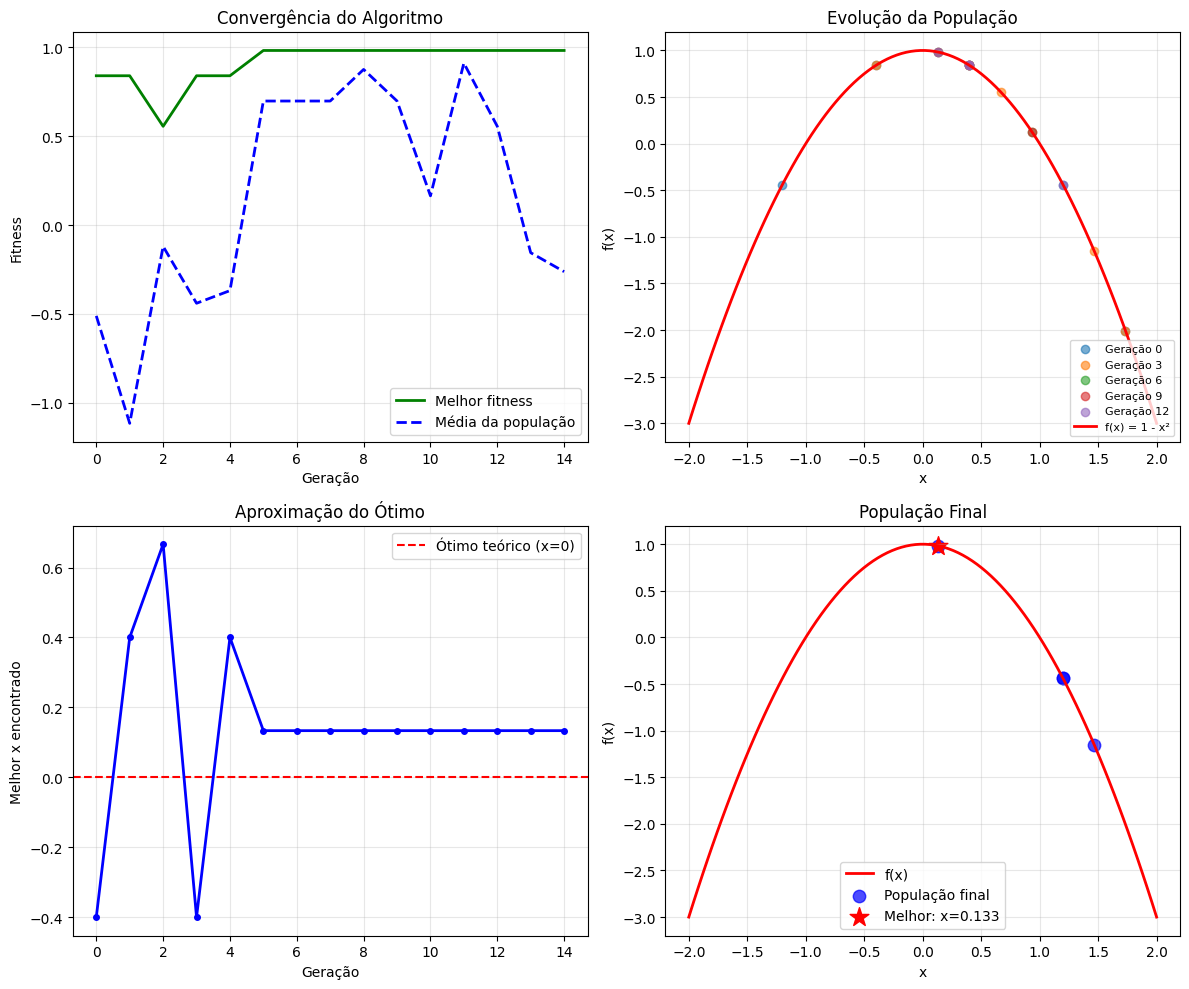


Resultado final:
Melhor x encontrado: 0.1333
Melhor f(x): 0.9822
Ótimo teórico: x = 0, f(x) = 1
Erro absoluto: |x - 0| = 0.1333


In [9]:
# Executar o AG
np.random.seed(42)  # para reprodutibilidade
historico = executar_ag_completo(tamanho_pop=4, n_geracoes=15, prob_mutacao=0.2)

# Criar visualização
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Convergência
ax1 = axes[0, 0]
geracoes = [h['geracao'] for h in historico]
melhores = [h['melhor_fitness'] for h in historico]
medias = [h['media_fitness'] for h in historico]
ax1.plot(geracoes, melhores, 'g-', linewidth=2, label='Melhor fitness')
ax1.plot(geracoes, medias, 'b--', linewidth=2, label='Média da população')
ax1.set_xlabel('Geração')
ax1.set_ylabel('Fitness')
ax1.set_title('Convergência do Algoritmo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Evolução da população (x)
ax2 = axes[0, 1]
for h in historico[::3]:  # plota a cada 3 gerações
    x_vals = h['x_vals']
    y_vals = h['fitness']
    ax2.scatter(x_vals, y_vals, alpha=0.6, label=f"Geração {h['geracao']}")
x_plot = np.linspace(-2, 2, 100)
ax2.plot(x_plot, f(x_plot), 'r-', linewidth=2, label='f(x) = 1 - x²')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Evolução da População')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, alpha=0.3)

# Gráfico 3: Melhor x ao longo das gerações
ax3 = axes[1, 0]
melhores_x = [h['melhor_x'] for h in historico]
ax3.axhline(y=0, color='r', linestyle='--', label='Ótimo teórico (x=0)')
ax3.plot(geracoes, melhores_x, 'b-o', linewidth=2, markersize=4)
ax3.set_xlabel('Geração')
ax3.set_ylabel('Melhor x encontrado')
ax3.set_title('Aproximação do Ótimo')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Distribuição final da população
ax4 = axes[1, 1]
final = historico[-1]
x_final = final['x_vals']
y_final = final['fitness']
x_plot = np.linspace(-2, 2, 100)
ax4.plot(x_plot, f(x_plot), 'r-', linewidth=2, label='f(x)')
ax4.scatter(x_final, y_final, c='blue', s=80, alpha=0.7, label='População final')
ax4.scatter(final['melhor_x'], final['melhor_fitness'], c='red', s=200, 
           marker='*', label=f"Melhor: x={final['melhor_x']:.3f}")
ax4.set_xlabel('x')
ax4.set_ylabel('f(x)')
ax4.set_title('População Final')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resultados
print(f"\nResultado final:")
print(f"Melhor x encontrado: {historico[-1]['melhor_x']:.4f}")
print(f"Melhor f(x): {historico[-1]['melhor_fitness']:.4f}")
print(f"Ótimo teórico: x = 0, f(x) = 1")
print(f"Erro absoluto: |x - 0| = {abs(historico[-1]['melhor_x']):.4f}")

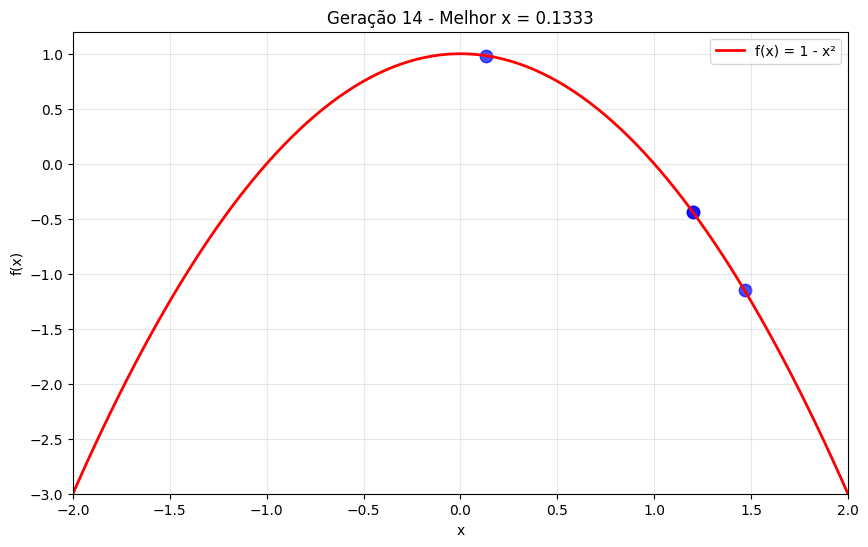

Fim da animação!


In [13]:
# Animação da evolução da população
fig, ax = plt.subplots(figsize=(10, 6))

x_plot = np.linspace(-2, 2, 100)
ax.plot(x_plot, f(x_plot), 'r-', linewidth=2, label='f(x) = 1 - x²')
ax.set_xlim(-2, 2)
ax.set_ylim(-3, 1.2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)
ax.legend()

scat = ax.scatter([], [], c='blue', s=80, alpha=0.7)

for geracao, dados in enumerate(historico):
    scat.set_offsets(np.c_[dados['x_vals'], dados['fitness']])
    ax.set_title(f'Geração {geracao} - Melhor x = {dados["melhor_x"]:.4f}')
    display(fig)
    clear_output(wait=True)
    time.sleep(0.5)
    
plt.show()
print("Fim da animação!")

In [12]:
print("Análise da discretização com 4 bits:")
print("="*50)
print(f"Número de pontos no grid: {2**n_bits}")
print(f"Espaçamento: Δx = {delta_x:.4f}")
print(f"x = 0 NÃO está no grid!")
print(f"Pontos mais próximos de 0:")
print(f"  • 0111 → x = {decimal_para_real(7):.4f} → f = {f(decimal_para_real(7)):.4f}")
print(f"  • 1000 → x = {decimal_para_real(8):.4f} → f = {f(decimal_para_real(8)):.4f}")
print(f"\nMelhor fitness possível com 4 bits: {max(f(decimal_para_real(d)) for d in range(16)):.4f}")
print(f"Este é o valor máximo que o AG pode encontrar devido à discretização!")

Análise da discretização com 4 bits:
Número de pontos no grid: 16
Espaçamento: Δx = 0.2667
x = 0 NÃO está no grid!
Pontos mais próximos de 0:
  • 0111 → x = -0.1333 → f = 0.9822
  • 1000 → x = 0.1333 → f = 0.9822

Melhor fitness possível com 4 bits: 0.9822
Este é o valor máximo que o AG pode encontrar devido à discretização!
